<a href="https://colab.research.google.com/github/Sampavi01/Hotel_Revenue_Forecasting/blob/forecasting/gru_optimizations/2gru_1dense.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# ================== IMPORTS ==================
import os
import random
import itertools
from datetime import timedelta, datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, Bidirectional, GlobalAveragePooling1D
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import RobustScaler

# ================== CONFIG / CONSTANTS ==================
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

tf.random.set_seed(42)
np.random.seed(42)

INPUT_FILE_NAME = 'Model_Training_Datasets.xlsx'

TEST_SET_DAYS = 60
VAL_DAYS = 90
N_SPLITS = 3  # Reduced for stability with smaller datasets
N_TIMESTEPS = 7

TARGET_RAW_COLS = ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']

LAG_DAYS = [1, 7, 14]
ROLL_WINDOWS = [7]

GRU_EPOCHS = 100
GRU_BATCH_SIZE = 16

SEARCH_SPACE_GRU_LR = [1e-4, 1e-3, 5e-3, 1e-2]
SEARCH_SPACE_GRU_UNITS = [64, 128, 256]

In [17]:
# ================== UTILITY FUNCTIONS ==================
def add_lag_and_rolling(df, target_cols, lag_days, roll_windows):
    df = df.copy()
    for col in target_cols:
        for lag in lag_days:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
        if pd.api.types.is_numeric_dtype(df[col]):
            for w in roll_windows:
                df[f'{col}_rollmean{w}'] = df[col].rolling(window=w, min_periods=1).mean().shift(1)
                df[f'{col}_rollstd{w}'] = df[col].rolling(window=w, min_periods=1).std().shift(1).fillna(0)
    return df.fillna(0)

def create_sequences(data, target, n_timesteps):
    X, y = [], []
    for i in range(len(data) - n_timesteps):
        X.append(data[i:(i + n_timesteps), :])
        y.append(target[i + n_timesteps])
    return np.array(X), np.array(y)

# ================== GRU MODEL  ==================
def build_bigru_model(input_shape_gru, lr, units):
    gru_input = Input(shape=input_shape_gru, name='gru_input')

    # Return sequences only for the first layer to stack them
    x = Bidirectional(GRU(units, return_sequences=True))(gru_input)
    x = Dropout(0.3)(x)

    # Final GRU layer returns only the last state to avoid "same length" array errors
    x = Bidirectional(GRU(units // 2, return_sequences=False))(x)
    x = Dropout(0.3)(x)

    x = Dense(units // 4, activation='relu')(x)
    output = Dense(1, activation='linear', name='output')(x)

    model = Model(inputs=gru_input, outputs=output)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# ================== PLOTTING FUNCTIONS ==================
def plot_results(history, test_df, center_name, meal_period):
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))

    # 1. Loss Curves
    ax[0].plot(history.history['loss'], label='Train Loss', color='blue')
    if 'val_loss' in history.history:
        ax[0].plot(history.history['val_loss'], label='Val Loss', color='orange')
    ax[0].set_title(f'Loss Curves: {center_name} - {meal_period}')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('MSE')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # 2. Actual vs Predicted
    ax[1].plot(test_df['Date'], test_df['Actual_Revenue'], label='Actual', marker='o', alpha=0.7)
    ax[1].plot(test_df['Date'], test_df['Predicted_Revenue'], label='Predicted', marker='x', color='red')
    ax[1].set_title(f'Actual vs Predicted (Test) - {center_name}')
    ax[1].set_xlabel('Date')
    ax[1].set_ylabel('Revenue')
    ax[1].legend()
    ax[1].tick_params(axis='x', rotation=45)
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [18]:
# ================== RANDOM SEARCH ==================
def random_search_tune(X_train_full, Y_train_full, tscv, raw_target_col,
                       numeric_features, categorical_features,
                       lr_list, units_list, n_trials=5):
    grid = list(itertools.product(lr_list, units_list))
    combos = random.sample(grid, min(n_trials, len(grid)))

    best_rmse = float('inf')
    best_params = grid[0]

    for lr, units in combos:
        fold_rmses = []
        for train_idx, val_idx in tscv.split(X_train_full):
            X_tr_raw, X_vl_raw = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
            Y_tr, Y_vl = Y_train_full.iloc[train_idx][raw_target_col], Y_train_full.iloc[val_idx][raw_target_col]

            scaler = RobustScaler()
            X_tr_s = scaler.fit_transform(X_tr_raw[numeric_features])
            X_vl_s = scaler.transform(X_vl_raw[numeric_features])

            X_seq_tr, Y_seq_tr = create_sequences(X_tr_s, Y_tr.values, N_TIMESTEPS)
            X_seq_vl, Y_seq_vl = create_sequences(X_vl_s, Y_vl.values, N_TIMESTEPS)

            if len(X_seq_tr) == 0 or len(X_seq_vl) == 0: continue

            tf.keras.backend.clear_session()
            model = build_bigru_model((N_TIMESTEPS, X_seq_tr.shape[2]), lr, units)
            model.fit(X_seq_tr, Y_seq_tr, epochs=15, verbose=0, batch_size=GRU_BATCH_SIZE)

            preds = model.predict(X_seq_vl, verbose=0).flatten()
            fold_rmses.append(np.sqrt(mean_squared_error(Y_seq_vl, preds)))

        if fold_rmses and np.mean(fold_rmses) < best_rmse:
            best_rmse = np.mean(fold_rmses)
            best_params = (lr, units)

    return best_rmse, best_params

In [19]:
# ================== MAIN TRAINING FUNCTION ==================
def train_and_plot_for_center(df_center, center_name):
    df_center = add_lag_and_rolling(df_center, TARGET_RAW_COLS, LAG_DAYS, ROLL_WINDOWS)
    df_center = df_center.sort_values('Date').reset_index(drop=True)

    test_start_date = df_center['Date'].max() - timedelta(days=TEST_SET_DAYS)
    df_train_full = df_center[df_center['Date'] < test_start_date].copy().dropna()
    df_test_full = df_center[df_center['Date'] >= test_start_date].copy()

    feature_cols = [c for c in df_train_full.columns if c not in ['Date'] + TARGET_RAW_COLS]
    numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_train_full[c])]
    categorical_features = [c for c in feature_cols if c not in numeric_features]

    X_train_all = df_train_full[feature_cols]
    Y_train_all = df_train_full[TARGET_RAW_COLS]

    for raw_target_col in TARGET_RAW_COLS:
        meal_period = raw_target_col.replace('Revenue_By_', '')
        print(f"\n--- Processing {meal_period} ---")

        # 1. Tune
        tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VAL_DAYS)
        best_rmse, (best_lr, best_units) = random_search_tune(
            X_train_all, Y_train_all, tscv, raw_target_col,
            numeric_features, categorical_features, SEARCH_SPACE_GRU_LR, SEARCH_SPACE_GRU_UNITS
        )

        # 2. Final Prepare
        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(df_train_full[numeric_features])
        X_seq_total, Y_seq_total = create_sequences(X_train_scaled, df_train_full[raw_target_col].values, N_TIMESTEPS)

        # Validation Split for final plot
        split_idx = int(len(X_seq_total) * 0.8)
        X_train_final, X_val_final = X_seq_total[:split_idx], X_seq_total[split_idx:]
        y_train_final, y_val_final = Y_seq_total[:split_idx], Y_seq_total[split_idx:]

        # 3. Train
        tf.keras.backend.clear_session()
        model = build_bigru_model((N_TIMESTEPS, X_train_final.shape[2]), best_lr, best_units)
        es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        history = model.fit(
            X_train_final, y_train_final,
            validation_data=(X_val_final, y_val_final),
            epochs=GRU_EPOCHS, batch_size=GRU_BATCH_SIZE, callbacks=[es], verbose=0
        )

        # 4. Predict on Test
        # Need to prepend the last N_TIMESTEPS from training to test set to predict the first few test days
        last_train_days = df_train_full[numeric_features].tail(N_TIMESTEPS)
        combined_test = pd.concat([last_train_days, df_test_full[numeric_features]])
        X_test_scaled = scaler.transform(combined_test)
        X_seq_test, _ = create_sequences(X_test_scaled, np.zeros(len(X_test_scaled)), N_TIMESTEPS)

        y_test_pred = model.predict(X_seq_test, verbose=0).flatten()

        # 5. Result Table
        res_df = pd.DataFrame({
            'Date': df_test_full['Date'].iloc[:len(y_test_pred)],
            'Actual_Revenue': df_test_full[raw_target_col].iloc[:len(y_test_pred)],
            'Predicted_Revenue': y_test_pred
        })

        # 6. Plot Everything
        plot_results(history, res_df, center_name, meal_period)


--- Processing BreakFast ---


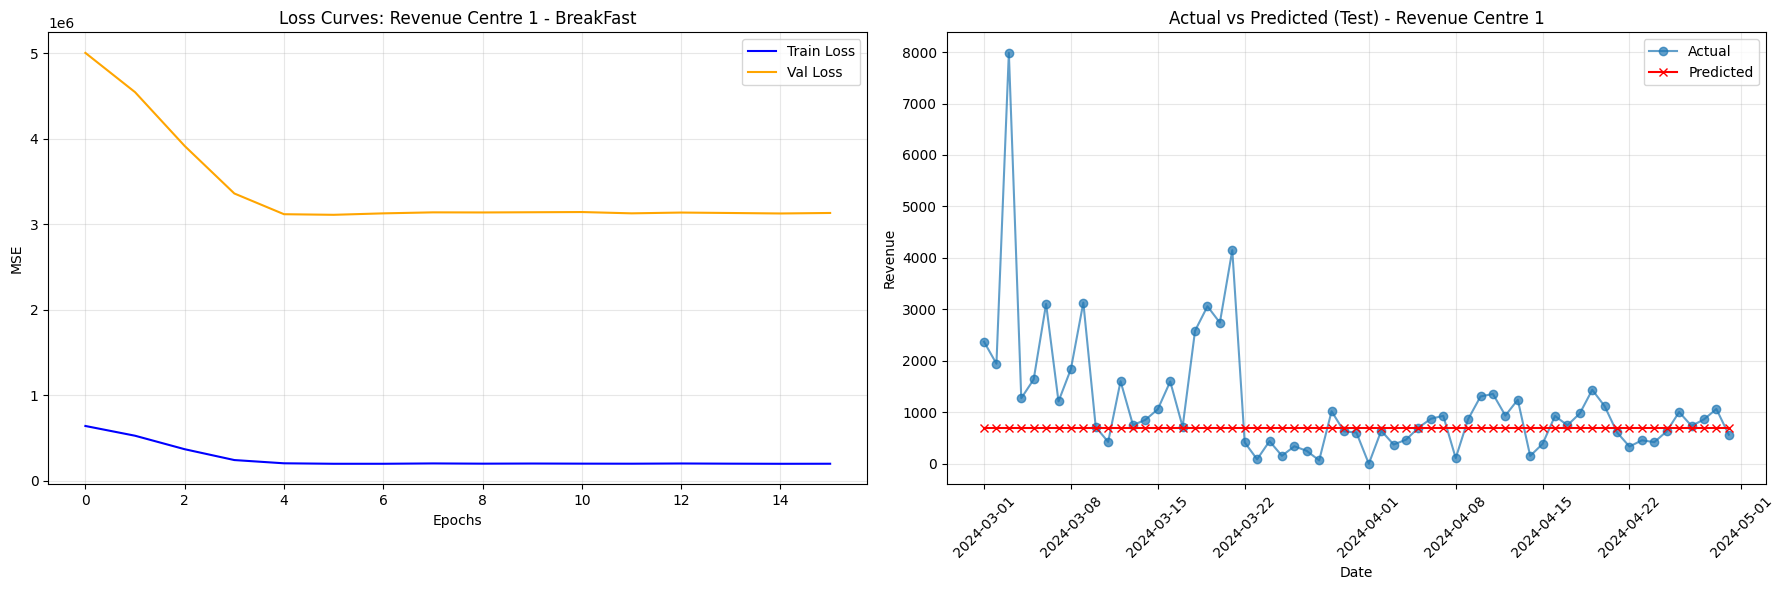


--- Processing Dinner ---


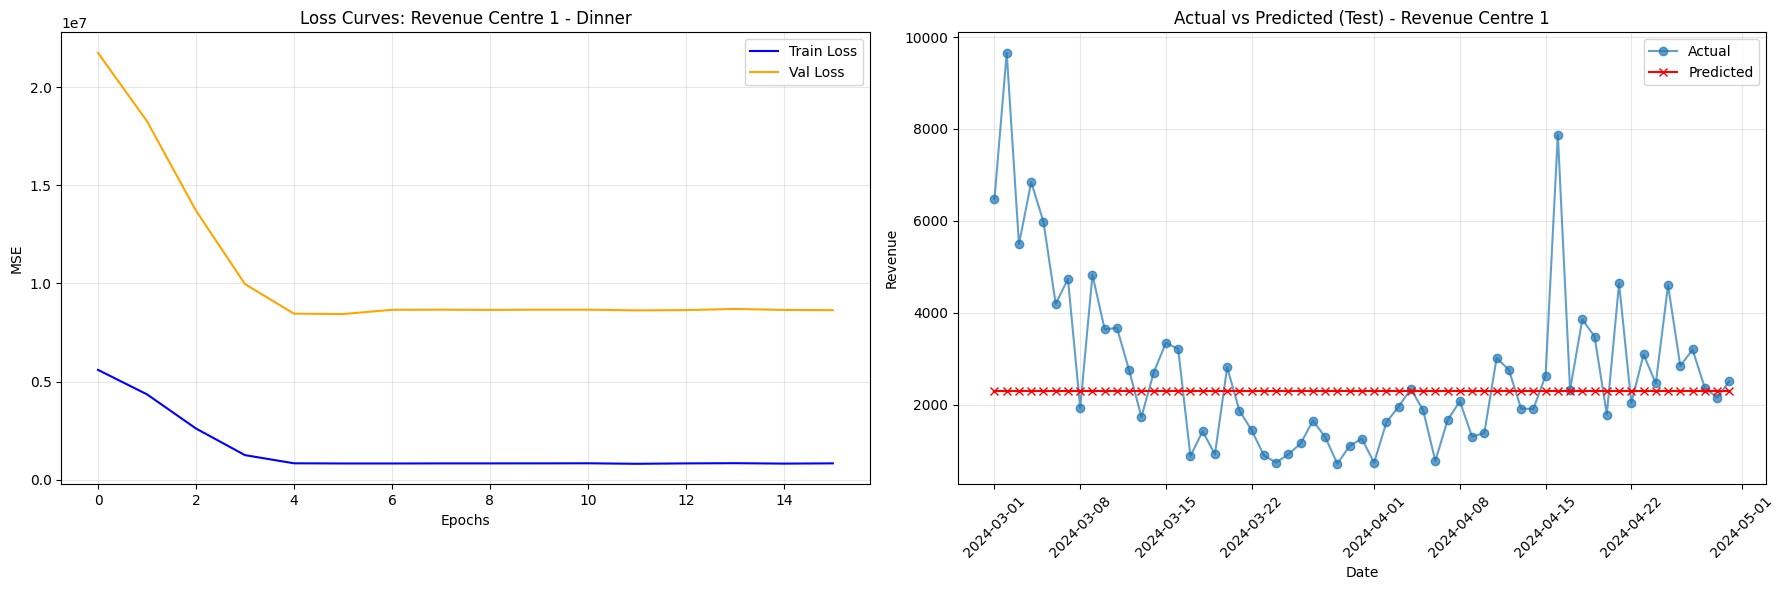


--- Processing Lunch ---


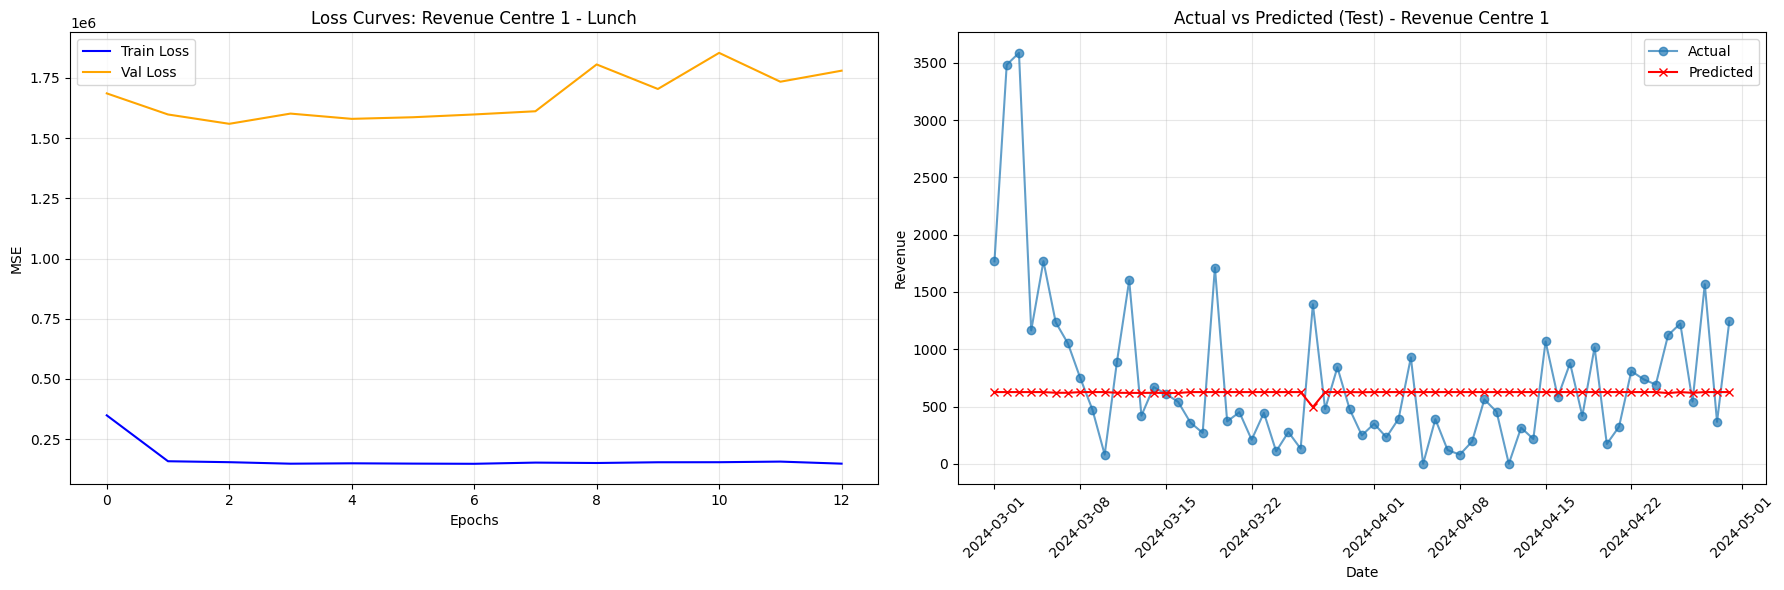

In [20]:
def load_center_from_excel(file_path, center_sheet_name):
    df = pd.read_excel(file_path, sheet_name=center_sheet_name)
    df['Date'] = pd.to_datetime(df['Date'])
    return df

if __name__ == '__main__':
    try:
        df_center_1 = load_center_from_excel(INPUT_FILE_NAME, 0)
        train_and_plot_for_center(df_center_1, "Revenue Centre 1")
    except Exception as e:
        print(f"CRITICAL ERROR: {e}")

## 📊 Model Performance Summary: Revenue Centre 1

### 1️⃣ Revenue Centre 1 – **Breakfast**
**Loss Behavior**  
- Training loss converges rapidly by **epoch 4**.  
- A **large generalization gap** is observed, with Validation Loss remaining significantly higher than Training Loss.

**Prediction Result**  
- The model collapses to a **Mean Predictor (Flat Line)** strategy.  
- Predicts a constant value of approximately **700 units** for every day.

**Observation**  
- The model completely fails to capture volatility.  
- Major spikes, such as the **~8,000 peak on March 1st**, are ignored.

---

### 2️⃣ Revenue Centre 1 – **Dinner**
**Loss Behavior**  
- Validation error scale is extremely large (**MSE ≈ 0.8 × 10⁷**).  
- Significantly higher than other meal periods.

**Prediction Result**  
- Produces a **Flat Line** prediction around **2,300 units**.  
- Actual values fluctuate between **800 and nearly 10,000 units**.

**Observation**  
- Severe **underfitting**.  
- The model defaults to predicting the statistical average to minimize large MSE penalties.

---

### 3️⃣ Revenue Centre 1 – **Lunch**
**Loss Behavior**  
- Validation Loss **increases after epoch 7**, while Training Loss remains flat.  
- Indicates instability and potential overfitting to noise.

**Prediction Result**  
- Generates a Flat Line prediction at approximately **600 units**.  
- A small downward dip appears in late March but does not align with real spikes.

**Observation**  
- Current feature set lacks sufficient predictive power.  
- Highly volatile lunch revenue patterns are not being captured.

---

## 🔍 Root Cause Analysis — *The “Flat Line” Problem*

The GRU model is struggling due to the following factors:

- **Extreme Outliers**  
  - Revenue spikes reaching **10,000 units** dominate the MSE loss.  
  - Predicting the mean becomes the safest strategy to avoid large penalties.

- **Missing Seasonality Information**  
  - Clear weekly and cyclical patterns (e.g., weekends) exist in the data.  
  - Absence of **Day-of-Week** features prevents the model from distinguishing demand cycles.

- **Underfitting**  
  - Persistent gap between training and validation loss across all meal periods.  
  - Indicates weak generalization and insufficient learning of temporal patterns.

---

## 🛠️ Proposed Optimization Strategy

To enable the model to follow real revenue spikes more accurately:

- **Log Transformation**  
  - Apply `log(1 + x)` to revenue targets to reduce the dominance of extreme peaks.

- **Feature Expansion**  
  - Add:
    - `DayOfWeek` (categorical)
    - `IsWeekend` (binary)  
  - Helps the model learn weekly seasonality patterns.

- **Robust Loss Function**  
  - Replace **MSE** with **Huber Loss**.  
  - Reduces sensitivity to outliers while preserving gradient stability.

---
